In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def generate_edge_points(length, width, height, points_per_edge):
    """
    Generate points along the edges of a rectangle defined by length, width, and height.
    """
    # Define the corners of the rectangle
    corners = np.array([
        [length / 2, width / 2, height / 2],
        [-length / 2, width / 2, height / 2],
        [-length / 2, -width / 2, height / 2],
        [length / 2, -width / 2, height / 2],
        [length / 2, width / 2, -height / 2],
        [-length / 2, width / 2, -height / 2],
        [-length / 2, -width / 2, -height / 2],
        [length / 2, -width / 2, -height / 2]
    ])
    
    # Edges are defined by pairs of indices into the corners array
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7)
    ]
    
    # Generate points along each edge
    points = []
    for start, end in edges:
        for i in range(points_per_edge):
            t = i / (points_per_edge - 1)
            point = (1 - t) * corners[start] + t * corners[end]
            points.append(point)
    
    return np.array(points)

def generate_rectangles_dataset(num_rectangles, total_points, lower_dim_limit, upper_dim_limit):
    dataset = np.zeros((num_rectangles, total_points, 4))
    points_per_edge = total_points // 12
    
    for i in range(num_rectangles):
        length, width, height = np.random.uniform(lower_dim_limit, upper_dim_limit, size=3)
        
        # Generate points on the edges of the rectangle
        edge_points = generate_edge_points(length, width, height, points_per_edge)
        
        # Assign points to dataset, with a random charge for each point
        for j in range(edge_points.shape[0]):
            x, y, z = edge_points[j]
            c = np.random.uniform(0, 1)  # Charge
            dataset[i, j] = [x, y, z, c]
    
    return dataset


def generate_noisy_edge_points(length, width, height, points_per_edge, noise_level=0.1):
    corners = np.array([
        [length / 2, width / 2, height / 2],
        [-length / 2, width / 2, height / 2],
        [-length / 2, -width / 2, height / 2],
        [length / 2, -width / 2, height / 2],
        [length / 2, width / 2, -height / 2],
        [-length / 2, width / 2, -height / 2],
        [-length / 2, -width / 2, -height / 2],
        [length / 2, -width / 2, -height / 2]
    ])
    
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7)
    ]
    
    points = []
    for start, end in edges:
        for i in range(points_per_edge):
            t = i / (points_per_edge - 1)
            point = (1 - t) * corners[start] + t * corners[end]
            # Add normal distribution noise to each point
            noise = np.random.normal(0, noise_level, size=3)
            noisy_point = point + noise
            points.append(noisy_point)
    
    return np.array(points)

def generate_noisy_edge_points(length, width, height, points_per_edge, noise_level=0.1):
    corners = np.array([
        [length / 2, width / 2, height / 2],
        [-length / 2, width / 2, height / 2],
        [-length / 2, -width / 2, height / 2],
        [length / 2, -width / 2, height / 2],
        [length / 2, width / 2, -height / 2],
        [-length / 2, width / 2, -height / 2],
        [-length / 2, -width / 2, -height / 2],
        [length / 2, -width / 2, -height / 2]
    ])
    
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7)
    ]
    
    points = []
    for start, end in edges:
        for i in range(points_per_edge):
            t = i / (points_per_edge - 1)
            point = (1 - t) * corners[start] + t * corners[end]
            # Add normal distribution noise to each point
            noise = np.random.normal(0, noise_level, size=3)
            noisy_point = point + noise
            points.append(noisy_point)
    
    return np.array(points)


def generate_noisy_rectangles_dataset(num_rectangles, total_points, lower_dim_limit, upper_dim_limit, noise_level=0.1):
    dataset = np.zeros((num_rectangles, total_points, 4))
    points_per_edge = total_points // 12
    
    for i in range(num_rectangles):
        length, width, height = np.random.uniform(lower_dim_limit, upper_dim_limit, size=3)
        
        # Generate noisy points on the edges of the rectangle
        edge_points = generate_noisy_edge_points(length, width, height, points_per_edge, noise_level)
        
        # Assign points to dataset, with a random charge for each point
        for j in range(edge_points.shape[0]):
            x, y, z = edge_points[j]
            c = np.random.uniform(0, 1)  # Charge
            dataset[i, j] = [x, y, z, c]
    
    return dataset


In [3]:
# Adjust these values as needed
num_rectangles = 1280
total_points = 256  # Should be a multiple of 12 for even distribution

dataset = generate_rectangles_dataset(num_rectangles, total_points, -2, 2)
dataset_noisy = generate_noisy_rectangles_dataset(num_rectangles, total_points, -2, 2)

# Save the datasets
np.save('rectangle.npy', dataset)
np.save('rectangle_noisy.npy', dataset_noisy)

In [4]:
print(dataset.shape, dataset_noisy.shape)

(1280, 256, 4) (1280, 256, 4)


In [6]:

def generate_triangular_prism_edge_points(side_length, height, points_per_edge):
    """
    Generate points along the edges of a triangular prism defined by side length and height.
    """
    # Define the vertices of the triangular prism
    sqrt_3 = np.sqrt(3) / 2
    corners = np.array([
        [0, side_length * sqrt_3, 0],               # Vertex 0, top triangle
        [-side_length / 2, 0, 0],                   # Vertex 1, top triangle
        [side_length / 2, 0, 0],                    # Vertex 2, top triangle
        [0, side_length * sqrt_3, height],          # Vertex 3, bottom triangle
        [-side_length / 2, 0, height],              # Vertex 4, bottom triangle
        [side_length / 2, 0, height]                # Vertex 5, bottom triangle
    ])
    
    # Define edges
    edges = [
        (0, 1), (1, 2), (2, 0),  # Top triangle edges
        (3, 4), (4, 5), (5, 3),  # Bottom triangle edges
        (0, 3), (1, 4), (2, 5)   # Connecting edges between top and bottom triangles
    ]
    
    # Generate points along each edge
    points = []
    for start, end in edges:
        for i in range(points_per_edge):
            t = i / (points_per_edge - 1)
            point = (1 - t) * corners[start] + t * corners[end]
            points.append(point)
    
    return np.array(points)

def generate_prism_datasets(num_prisms, total_points, side_length_range, height_range, noise_level=0):
    dataset = np.zeros((num_prisms, total_points, 4))
    points_per_edge = total_points // 9  # 9 edges in a triangular prism
    
    for i in range(num_prisms):
        side_length = np.random.uniform(*side_length_range)
        height = np.random.uniform(*height_range)
        
        # Generate points on the edges of the prism
        edge_points = generate_triangular_prism_edge_points(side_length, height, points_per_edge)
        
        if noise_level > 0:
            edge_points += np.random.normal(0, noise_level, edge_points.shape)
        
        # Assign points to dataset, with a random charge for each point
        for j in range(edge_points.shape[0]):
            x, y, z = edge_points[j]
            c = np.random.uniform(0, 1)  # Charge
            dataset[i, j] = [x, y, z, c]
    
    return dataset





In [7]:
# Example usage
num_prisms = 1280
total_points = 256
side_length_range = (-2, 2)
height_range = (-2, 2)
noise_level = 0.1  # Set to 0 for no noise

# Generate datasets
prism_dataset = generate_prism_datasets(num_prisms, total_points, side_length_range, height_range)
noisy_prism_dataset = generate_prism_datasets(num_prisms, total_points, side_length_range, height_range, noise_level)

np.save('triangle.npy', prism_dataset)
np.save('triangle_noisy.npy', noisy_prism_dataset)

In [ ]:
def generate_line_points(z_start, z_end, total_points, y_value):
    """
    Generate points along a line primarily extending along the z-axis from z_start to z_end.
    The y value is fixed for all points within a line but differs across lines.
    """
    zs = np.linspace(z_start, z_end, total_points)
    points = np.zeros((total_points, 3))
    points[:, 1] = y_value  # Fixed y value for all points in the line
    points[:, 2] = zs  # z-coordinates vary along the line
    return points

def generate_noisy_line_points(z_start, z_end, total_points, y_value):
    """
    Generate noisy points along a line extending along the z-axis from z_start to z_end.
    The y value is fixed for all points within a line but differs across lines. 
    Noise is added to the x and y dimensions, with the noise level in the y dimension 
    increasing based on the fixed y value for the line.
    """
    zs = np.linspace(z_start, z_end, total_points)
    points = np.zeros((total_points, 3))
    
    # Increase noise level for the fixed y value
    noise_level = y_value * 0.1  # Adjust this factor as needed
    
    noise_x = np.random.normal(0, noise_level, total_points)
    # For y, the noise is added around the fixed y value
    noise_y = np.random.normal(y_value, noise_level, total_points)
    
    points[:, 0] = noise_x  # Apply noise to x-coordinate
    points[:, 1] = noise_y  # Apply variable noise to fixed y-coordinate
    points[:, 2] = zs  # Set z-coordinate
    
    return points

def generate_lines_dataset(num_lines, total_points, z_range, y_range, noisy=False):
    """
    Generate a dataset of 3D line point clouds along the z-axis, with each line having a fixed y value.
    An option for adding noise is available, which affects the x and y dimensions.
    """
    z_start, z_end = z_range
    dataset = np.zeros((num_lines, total_points, 4))  # 3 coordinates + 1 charge
    
    for i in range(num_lines):
        # Generate a fixed y value for each line
        y_value = np.random.uniform(*y_range)
        
        if noisy:
            points = generate_noisy_line_points(z_start, z_end, total_points, y_value)
        else:
            points = generate_line_points(z_start, z_end, total_points, y_value)
        
        # Assign points to dataset, with a random charge for each point
        for j in range(points.shape[0]):
            x, y, z = points[j]
            c = np.random.uniform(0, 1)  # Charge
            dataset[i, j] = [x, y, z, c]
    
    return dataset

In [ ]:
# Example usage
num_lines = 1280
total_points = 256  # Total points per line
z_range = (-2, 2)  # Range for the z-axis
y_range = (0, 2)  # Range for generating fixed y values for each line

dataset = generate_lines_dataset(num_lines, total_points, z_range, y_range)
dataset_noisy = generate_lines_dataset(num_lines, total_points, z_range, y_range, noisy=True)

# Save the datasets
np.save('line.npy', dataset)
np.save('line_noisy.npy', dataset_noisy)

In [ ]:
print(dataset.shape, dataset_noisy.shape)

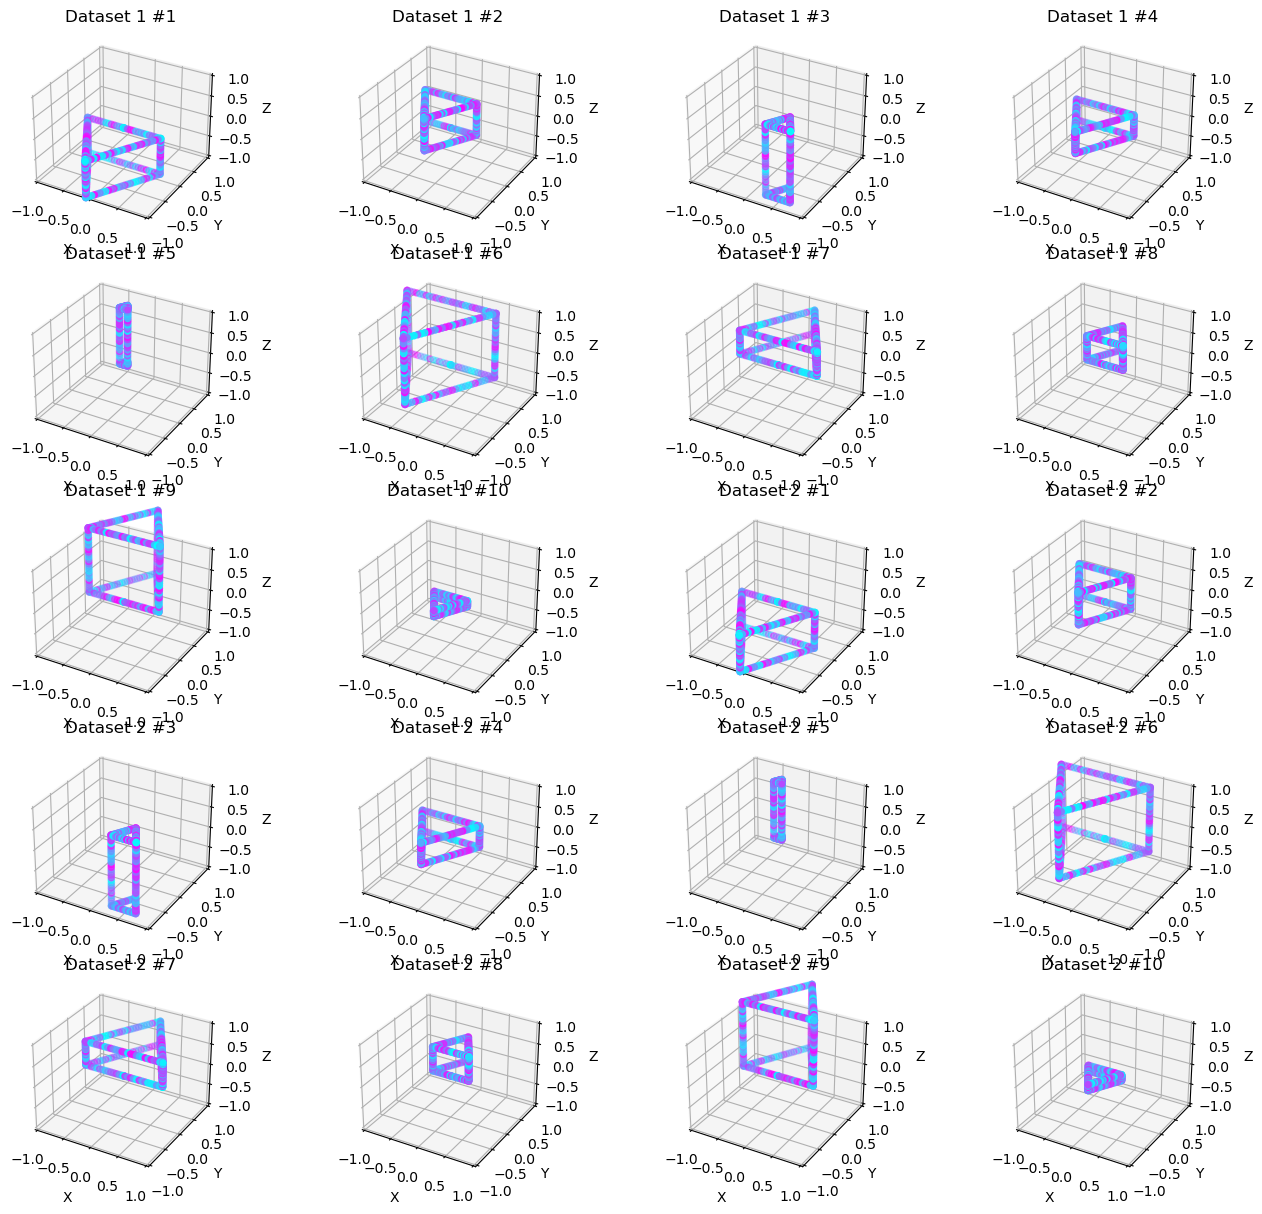

In [8]:
def visualize_datasets(path_dataset1, path_dataset2, title1='Dataset 1', title2='Dataset 2'):
    # Load the datasets
    dataset1 = np.load(path_dataset1)
    dataset2 = np.load(path_dataset2)
    
    fig = plt.figure(figsize=(14, 12))

    for i in range(10):
        ax = fig.add_subplot(5, 4, i + 1, projection='3d', title=f'{title1} #{i+1}')
        ax.scatter(dataset1[i, :, 0], dataset1[i, :, 1], dataset1[i, :, 2], c=dataset1[i, :, 3], cmap='cool', marker='o')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])

    for i in range(10):
        ax = fig.add_subplot(5, 4, i + 11, projection='3d', title=f'{title2} #{i+1}')
        ax.scatter(dataset2[i, :, 0], dataset2[i, :, 1], dataset2[i, :, 2], c=dataset2[i, :, 3], cmap='cool')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])

    plt.tight_layout()
    plt.show()

visualize_datasets('triangle.npy', 'triangle.npy')



In [ ]:
file_path1 = "rectangle_noisy.npy"
file_path2 = "triangle_noisy.npy"
data1 = np.load(file_path1)
data2 = np.load(file_path2)

combined_data = np.concatenate((data1, data2), axis=0)
np.random.shuffle(combined_data)

np.save("mix_noisy", combined_data)